## **Projet de classification d'image de cellules afin de détecter le parasite de la Malaria** ##

In [21]:
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import os
%reload_ext autoreload
%autoreload 2
import Partie_1_Pre_Traitement as pre_traitement
import Partie_2_MLP as mlp
import Partie_3_Evaluation as eval
import affichages as aff

### 1. Chargement du jeu de donnée ###

In [8]:
data, target, filenames, proc_imgs = mlp.load_images(
    "Uninfected",
    "Parasitized",
    return_meta = True
)

data = np.asarray(data)
target = np.asarray(target)

print(data)
print(data.shape)
print(data.min())
print(data.max())
print(data.mean())

[[-0.17836037 -0.17836037 -0.17836037 ... -0.17836037 -0.17836037
  -0.17836037]
 [-0.27239215  0.869243   -0.09941718 ... -0.27239215 -0.27239215
  -0.27239215]
 [-2.200845   -2.200845   -2.200845   ... -2.200845   -2.200845
  -2.200845  ]
 ...
 [-1.1849682  -1.1849682  -1.1849682  ... -1.1849682  -1.1849682
  -1.1849682 ]
 [-1.2570709  -1.2570709  -1.2570709  ... -1.1207205  -1.2570709
  -1.2570709 ]
 [-0.6741721  -0.6741721  -0.6741721  ... -0.6741721  -0.6741721
  -0.6741721 ]]
(2000, 256)
-2.836488
15.925237
2.2053719e-09


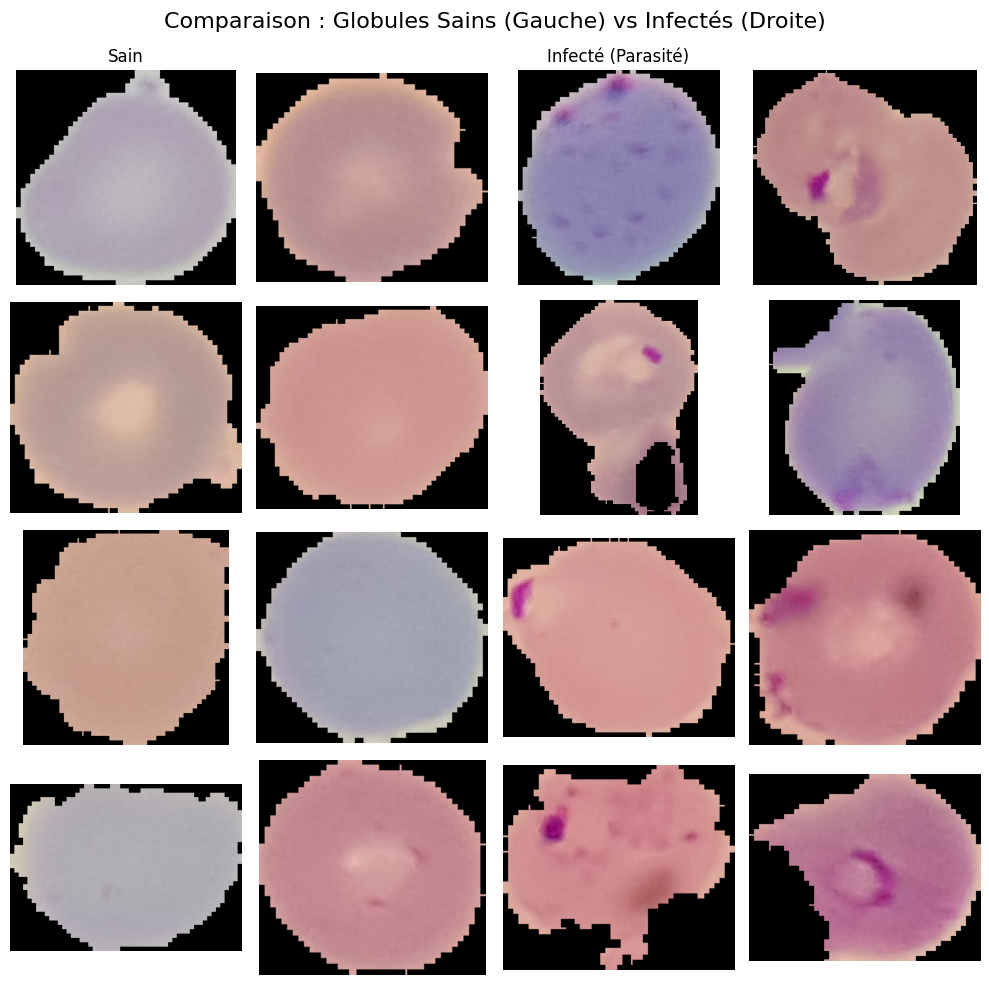

In [23]:
UNINFECTED_PATH = r"C:\Users\Capucine\OneDrive\Desktop\BTBI\3 BTBI\S2\PIML\Projet\Projet_PIML\Uninfected"
PARASITIZED_PATH = r"C:\Users\Capucine\OneDrive\Desktop\BTBI\3 BTBI\S2\PIML\Projet\Projet_PIML\Parasitized"

aff.plot_image_grid(UNINFECTED_PATH, PARASITIZED_PATH)

### 2. Test du modèle simple ###

In [9]:
best_result, all_results = mlp.grid_search_hyperparameters(data, target,
    train_func=mlp.mlp_fit,
    predict_func=mlp.predict,
    learning_rates=[0.1, 0.05, 0.01],
    n_epochs_values=[50,100,200],
    n_folds=5,
    hidden_layer_sizes=[32, 16],
    random_state=42
)


KeyboardInterrupt: 

In [44]:
best_lr = best_result['learning_rate']
best_epochs = best_result['n_epochs']
modele_simple = mlp.cross_validation(data, target, mlp.mlp_fit, mlp.predict, n_folds=5, learning_rate=best_lr, n_epochs=best_epochs)
mlp.save_model(modele_simple, "modele_simple.pkl")


===== Fold 1 =====
Accuracy: 0.7025

===== Fold 2 =====
Accuracy: 0.7100

===== Fold 3 =====
Accuracy: 0.6950

===== Fold 4 =====
Accuracy: 0.6925

===== Fold 5 =====
Accuracy: 0.6925

Accuracy moyenne: 0.6985


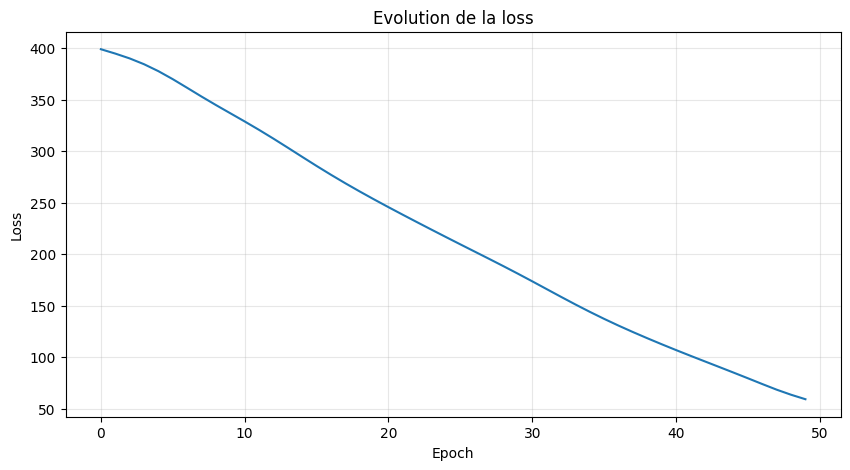

In [45]:
mlp.plot_losses(modele_simple['losses'])

### 3. Test du modèle ReLu ###

In [49]:
best_result_relu, all_results_relu = mlp.grid_search_hyperparameters(data, target,
    train_func=mlp.mlp_fit_relu,
    predict_func=mlp.predict_relu,
    learning_rates=[0.1, 0.05, 0.01, 0.005, 0.001],
    n_epochs_values=[4, 10, 20, 50],
    n_folds=5,
    hidden_layer_sizes=[32, 16],
    random_state=42
)


c:\Users\Capucine\OneDrive\Desktop\BTBI\3 BTBI\S2\PIML\Projet\Projet_PIML\Partie_2_MLP.py:84: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


Meilleurs hyperparametres
learning_rate: 0.05
n_epochs: 50
accuracy moyenne: 0.6945


In [47]:
best_lr_relu = best_result_relu['learning_rate']
best_epochs_relu = best_result_relu['n_epochs']

modele_relu = mlp.cross_validation(data, target, mlp.mlp_fit_relu, mlp.predict_relu, n_folds=5, learning_rate=best_lr_relu, n_epochs=best_epochs_relu)
mlp.save_model(modele_relu, "modele_relu.pkl")


===== Fold 1 =====
Accuracy: 0.7375

===== Fold 2 =====
Accuracy: 0.7000

===== Fold 3 =====
Accuracy: 0.6700

===== Fold 4 =====
Accuracy: 0.6975

===== Fold 5 =====
Accuracy: 0.6675

Accuracy moyenne: 0.6945


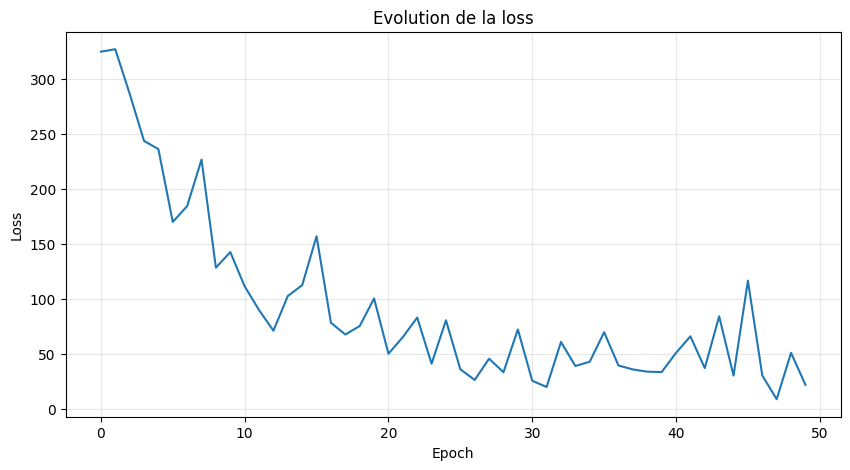

In [50]:
mlp.plot_losses(modele_relu['losses'])

### 4. Test du modèle avec Binary Cross Entropy ###

In [52]:
best_result_bce, all_results_bce = mlp.grid_search_hyperparameters(data, target,
    train_func=mlp.mlp_fit_bce,
    predict_func=mlp.predict_relu,
    learning_rates=[0.1, 0.05, 0.01, 0.005, 0.001],
    n_epochs_values=[4, 10, 20, 50],
    n_folds=5,
    hidden_layer_sizes=[32, 16],
    random_state=42
)


c:\Users\Capucine\OneDrive\Desktop\BTBI\3 BTBI\S2\PIML\Projet\Projet_PIML\Partie_2_MLP.py:84: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


Meilleurs hyperparametres
learning_rate: 0.01
n_epochs: 50
accuracy moyenne: 0.7015


In [54]:
best_lr_bce = best_result_bce['learning_rate']
best_epochs_bce = best_result_bce['n_epochs']
modele_bce = mlp.cross_validation(data, target, mlp.mlp_fit_bce, mlp.predict_relu, n_folds=5, learning_rate=best_lr_bce, n_epochs=best_epochs_bce)
mlp.save_model(modele_bce, "modele_bce.pkl")


===== Fold 1 =====
Accuracy: 0.7325

===== Fold 2 =====
Accuracy: 0.6875

===== Fold 3 =====
Accuracy: 0.7000

===== Fold 4 =====
Accuracy: 0.7025

===== Fold 5 =====
Accuracy: 0.6850

Accuracy moyenne: 0.7015


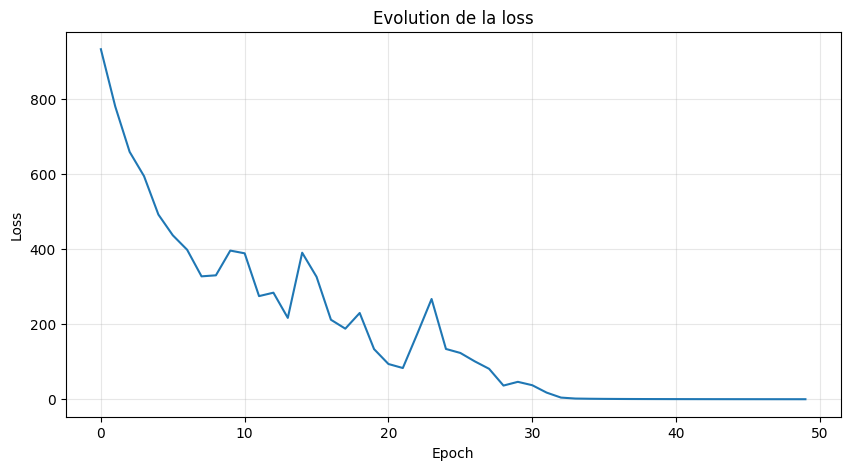

In [55]:
mlp.plot_losses(modele_bce['losses'])

### 5. Test du modèle avec Dropout ###

In [72]:
best_result_dropout, all_results_dropout = mlp.grid_search_hyperparameters(data, target,
    train_func=mlp.mlp_fit_dropout,
    predict_func=mlp.predict_dropout,
    learning_rates=[0.1, 0.05, 0.01, 0.005, 0.001],
    n_epochs_values=[4, 10, 20, 50],
    n_folds=5,
    hidden_layer_sizes=[32, 16],
    random_state=42
)

c:\Users\Capucine\OneDrive\Desktop\BTBI\3 BTBI\S2\PIML\Projet\Projet_PIML\Partie_2_MLP.py:84: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-z))


Meilleurs hyperparametres
learning_rate: 0.01
n_epochs: 50
accuracy moyenne: 0.7160


In [60]:
best_lr_dropout = best_result_dropout['learning_rate']
best_epochs_dropout = best_result_dropout['n_epochs']
modele_dropout = mlp.cross_validation(data, target, mlp.mlp_fit_dropout, mlp.predict_dropout, n_folds=5, learning_rate=best_lr_dropout, n_epochs=best_epochs_dropout)
mlp.save_model(modele_dropout, "modele_dropout.pkl")


===== Fold 1 =====
Accuracy: 0.7425

===== Fold 2 =====
Accuracy: 0.7250

===== Fold 3 =====
Accuracy: 0.7050

===== Fold 4 =====
Accuracy: 0.6925

===== Fold 5 =====
Accuracy: 0.7150

Accuracy moyenne: 0.7160


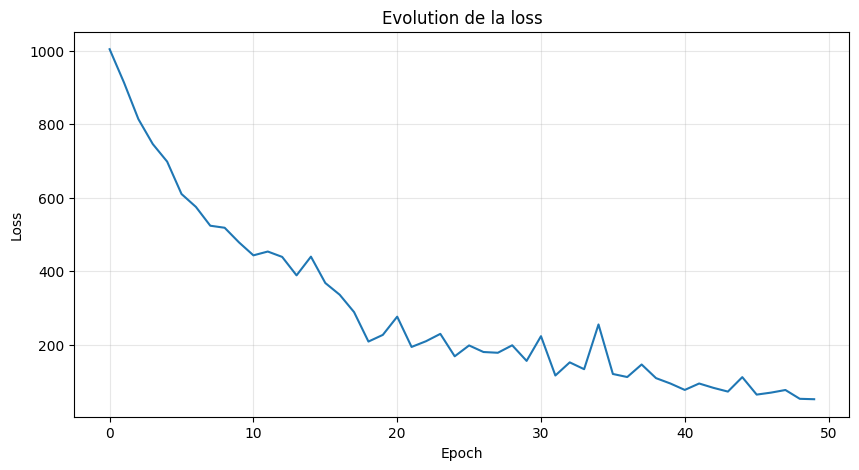

In [61]:
mlp.plot_losses(modele_dropout['losses'])

## 6. Test du modèle avec Mini Batch Gradient ##

In [74]:
best_result_minibatch, all_results_minibatch = mlp.grid_search_hyperparameters(data, target,
    train_func=mlp.mlp_fit_minibatch,
    predict_func=mlp.predict_relu,
    learning_rates=[0.1, 0.05, 0.01, 0.005, 0.001],
    n_epochs_values=[50, 100, 200],
    n_folds=5,
    hidden_layer_sizes=[32, 16],
    random_state=42,
    activation = "relu",
    loss = "bce",
    dropout_rate = 0.1
)

Meilleurs hyperparametres
learning_rate: 0.05
n_epochs: 200
accuracy moyenne: 0.7130


In [80]:
best_lr_minibatch = best_result_minibatch['learning_rate']
best_epochs_minibatch = best_result_minibatch['n_epochs']
modele_minibatch = mlp.cross_validation(data, target, mlp.mlp_fit_minibatch, mlp.predict_relu, n_folds=5, learning_rate=best_lr_minibatch, n_epochs=best_epochs_minibatch, dropout_rate=0.1)
mlp.save_model(modele_minibatch, "modele_minibatch.pkl")


===== Fold 1 =====
Accuracy: 0.7425

===== Fold 2 =====
Accuracy: 0.7100

===== Fold 3 =====
Accuracy: 0.7150

===== Fold 4 =====
Accuracy: 0.7000

===== Fold 5 =====
Accuracy: 0.6975

Accuracy moyenne: 0.7130


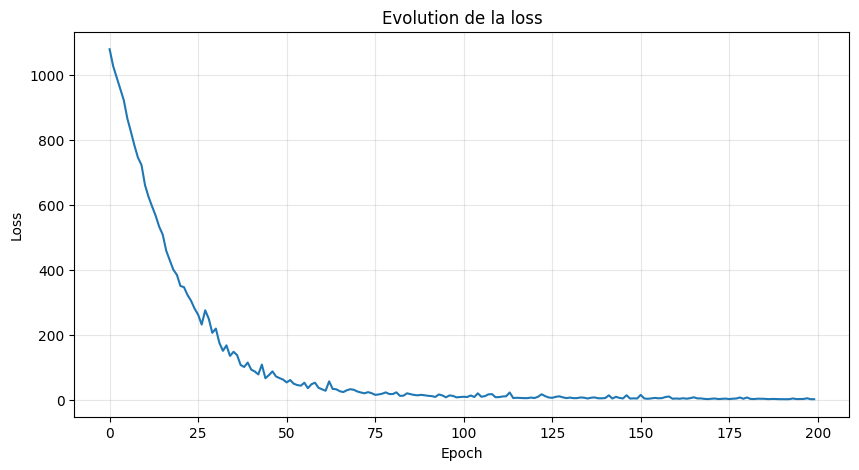

In [81]:
mlp.plot_losses(modele_minibatch['losses'])